# Sentiment Analysis V5 — CNN, BiLSTM, dan Hybrid CNN-BiLSTM Text-Emoji

Notebook ini digunakan untuk membandingkan tiga model deep learning pada analisis sentimen berbasis teks dan emoji:

1. CNN Standalone
2. BiLSTM Standalone
3. Hybrid CNN-BiLSTM

Perbaikan utama pada V5:

- Tidak melakukan oversampling sebelum split agar tidak terjadi data leakage.
- Mempertahankan tag emoji dalam format `<nama_emoji>` agar emoji dapat diproses sebagai fitur khusus.
- Menggunakan dua jalur embedding:
  - Teks → Word2Vec embedding
  - Emoji → trainable emoji embedding
- Menggunakan preprocessing, split data, tokenizer, dan embedding yang sama untuk semua model.
- Membangun hybrid CNN-BiLSTM secara sequential, yaitu CNN terlebih dahulu untuk ekstraksi fitur lokal, kemudian BiLSTM untuk menangkap konteks sekuensial.

Tujuan eksperimen adalah mengevaluasi apakah model hybrid CNN-BiLSTM yang sesuai paper mampu memberikan performa lebih baik dibandingkan model CNN dan BiLSTM standalone.

In [2]:
# ============================================================
# 0. INSTALL DEPENDENCIES
# ============================================================

!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.0 MB/s eta 0:00:00


In [3]:
# ============================================================
# 1. IMPORT LIBRARY DAN SETUP ENVIRONMENT
# ============================================================

import os
import re
import time
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Dense,
    Dropout,
    SpatialDropout1D,
    Concatenate,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Bidirectional,
    LSTM,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from gensim.models import Word2Vec

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("Setup selesai.")

Setup selesai.


# 2. Load dan Merge Dataset

Dataset yang digunakan terdiri dari dua file:

1. `data_bersih.csv`, dengan label dari kolom `label_saat_ini`.
2. `data_relabel_labeled.csv`, dengan label dari kolom `label_gemini`.

Kedua dataset digabung menjadi dua kolom utama, yaitu `tweet` dan `label`. Setelah itu dilakukan penghapusan data kosong dan duplikasi tweet untuk mencegah data leakage.

In [6]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

print("Google Drive berhasil di-mount.")

Mounted at /content/drive
Google Drive berhasil di-mount.


In [7]:
# ============================================================
# 2. LOAD DAN MERGE DATASET
# ============================================================

path_data_bersih = "/content/drive/MyDrive/3. KULIAH/SEMESTER 6/1. KULIAH/2-DL/3-final-project/datasets/data_bersih.csv"
path_data_relabel = "/content/drive/MyDrive/3. KULIAH/SEMESTER 6/1. KULIAH/2-DL/3-final-project/datasets/data_relabel_labeled.csv"

data_bersih = pd.read_csv(path_data_bersih)
data_relabel = pd.read_csv(path_data_relabel)

df_bersih = data_bersih[['tweet', 'label_saat_ini']].copy()
df_bersih = df_bersih.rename(columns={'label_saat_ini': 'label'})

df_relabel = data_relabel[['tweet', 'label_gemini']].copy()
df_relabel = df_relabel.rename(columns={'label_gemini': 'label'})

df = pd.concat([df_bersih, df_relabel], ignore_index=True)

df = df.dropna(subset=['tweet', 'label']).copy()
df['tweet'] = df['tweet'].astype(str)
df['label'] = df['label'].astype(str).str.lower().str.strip()

label_valid = ['negatif', 'netral', 'positif']
df = df[df['label'].isin(label_valid)].copy()

before_dedup = len(df)
df = df.drop_duplicates(subset=['tweet']).reset_index(drop=True)
after_dedup = len(df)

print("Jumlah data sebelum deduplikasi:", before_dedup)
print("Jumlah data setelah deduplikasi :", after_dedup)
print("Jumlah duplikat dihapus        :", before_dedup - after_dedup)

print("\nDistribusi label:")
print(df['label'].value_counts())

print("\nPersentase label:")
print((df['label'].value_counts(normalize=True) * 100).round(2))

display(df.head())

Jumlah data sebelum deduplikasi: 27211
Jumlah data setelah deduplikasi : 15012
Jumlah duplikat dihapus        : 12199

Distribusi label:
label
positif    6983
negatif    6233
netral     1796
Name: count, dtype: int64

Persentase label:
label
positif    46.52
negatif    41.52
netral     11.96
Name: proportion, dtype: float64


,tweet,label
0,wah belom liat muka gue lagi murka hahahaha <Wajah Bersungut Marah> <Wajah Mengeluarkan Uap Dari Hidung>,negatif
1,"Lho kok buru-buru mengatakan orang marah? <Wajah Memutar Mata> Keknya anda salah tafsir. <Wajah Tidak Terhibur> Bukan marah sih, cuma mual-mual karena jijik. <Wajah Mual>",negatif
2,"Apalagi yang jualan Spotify premium banyak banget, lama-lama bikin risih <Wajah Tidak Terhibur> <Wajah Memutar Mata>",negatif
3,Buaya darat buset aku tertipu lagi <Wajah Menangis Kencang> <Hati Patah>,negatif
4,Semoga jangan deh <Wajah Berteriak Ketakutan> . Aku juga semingguan ini mimpi aneh aneh random bgt jadi takut kalo beneran kenyataan <Wajah Mulut Terbuka Dan Keringat Dingin>,negatif


# 3. Preprocessing Emoji-Safe

Tahap ini digunakan untuk membersihkan teks tanpa merusak tag emoji.

Pada dataset, emoji sudah berbentuk deskripsi dalam tanda kurung sudut, misalnya:

`<Wajah Bersungut Marah>`

Agar emoji tetap dapat diproses sebagai fitur khusus, tag emoji tersebut tidak boleh dihapus atau dipecah menjadi kata biasa. Oleh karena itu, tag emoji dinormalisasi menjadi satu token dengan format:

`<wajah_bersungut_marah>`

Preprocessing yang dilakukan meliputi:

1. Mengubah teks menjadi huruf kecil.
2. Menghapus URL, mention, hashtag, angka, dan karakter yang tidak diperlukan.
3. Melakukan normalisasi kata tidak baku.
4. Mempertahankan tag emoji berbentuk `<...>`.
5. Mengubah spasi di dalam tag emoji menjadi underscore agar emoji tetap menjadi satu token.

In [14]:
def normalize_emoji_tag(text):
    """
    Menyatukan spasi di dalam tag emoji agar menjadi satu token.
    Juga memperbaiki kasus tag rusak seperti <<Wajah ...> menjadi <wajah_...>.
    """
    text = str(text)

    # Perbaiki tanda kurung sudut berlebihan
    text = re.sub(r'<+', '<', text)
    text = re.sub(r'>+', '>', text)

    # Normalisasi isi tag emoji
    text = re.sub(
        r'<([^>]+)>',
        lambda m: '<' + m.group(1).lower().strip().replace(' ', '_') + '>',
        text
    )

    return text

In [15]:
# ============================================================
# 3. PREPROCESSING EMOJI-SAFE
# ============================================================

kamus_slang = {
    "yg": "yang", "ye": "iya", "yak": "iya",
    "ama": "sama", "sm": "sama",
    "dgn": "dengan", "dg": "dengan",
    "kalo": "kalau", "klo": "kalau", "kl": "kalau",
    "karna": "karena", "krn": "karena",
    "tp": "tetapi", "utk": "untuk", "kpd": "kepada",
    "pdhl": "padahal", "blm": "belum", "smoga": "semoga",
    "sdh": "sudah", "udh": "sudah", "udah": "sudah", "bgt": "banget",
    "lgi": "lagi", "lg": "lagi", "dr": "dari", "dri": "dari",
    "bs": "bisa", "jd": "jadi", "jdi": "jadi", "jg": "juga",
    "gw": "saya", "gue": "saya", "w": "saya", "aq": "saya",
    "lu": "kamu", "loe": "kamu", "lo": "kamu", "elu": "kamu",
    "org": "orang", "sampe": "sampai",
    "aja": "saja", "gitu": "begitu", "bikin": "membuat",
    "liat": "lihat", "tau": "tahu",
    "pengen": "ingin", "pen": "ingin",
    "cuma": "hanya", "cuman": "hanya",
    "males": "malas",
    "gapapa": "tidak apa-apa", "gpp": "tidak apa-apa",
    "ga": "tidak", "gak": "tidak", "gk": "tidak",
    "tdk": "tidak", "nggak": "tidak", "g": "tidak",
    "bner": "benar", "bener": "benar",
    "dah": "sudah",
    "happy": "senang", "birthday": "ulang tahun",
    "congrats": "selamat",
    "sad": "sedih", "angry": "marah"
}


def normalize_emoji_tag(text):
    """
    Menyatukan spasi di dalam tag emoji agar menjadi satu token.
    Contoh:
    <Wajah Bersungut Marah> -> <wajah_bersungut_marah>
    """
    return re.sub(
        r'<([^>]+)>',
        lambda m: '<' + m.group(1).lower().strip().replace(' ', '_') + '>',
        str(text)
    )


def clean_text_keep_emoji(text):
    """
    Membersihkan teks sambil mempertahankan emoji tag <...>.
    """
    if not isinstance(text, str):
        return ""

    # Normalisasi tag emoji lebih dulu agar tidak pecah
    text = normalize_emoji_tag(text)

    # Lowercase
    text = text.lower()

    # Hapus URL, mention, dan simbol hashtag
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\S+', ' ', text)
    text = re.sub(r'#', '', text)

    # Hapus karakter selain huruf, spasi, underscore, dan tanda < >
    # Underscore dipertahankan agar <wajah_marah> tidak rusak
    text = re.sub(r'[^a-z_\s<>]', ' ', text)

    # Hapus pola tawa berulang
    text = re.sub(r'\b(?:wk|wkwk|haha|hehe|hihi|xixi)+\b', ' ', text)

    # Normalisasi huruf berulang, contoh: baguuuus -> bagus
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Normalisasi slang, tapi jangan ubah token emoji
    words = text.split()
    clean_words = []

    for word in words:
        if word.startswith('<') and word.endswith('>'):
            clean_words.append(word)
        else:
            formal = kamus_slang.get(word, word)
            if len(formal) > 1:
                clean_words.append(formal)

    text = " ".join(clean_words)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Bentuk dataframe kerja
df_model = df[['tweet', 'label']].copy()
df_model = df_model.rename(columns={'tweet': 'text'})

# Terapkan preprocessing
df_model['text_clean'] = df_model['text'].apply(clean_text_keep_emoji)

print("Contoh hasil preprocessing emoji-safe:")
display(df_model[['text', 'text_clean', 'label']].head(10))

Contoh hasil preprocessing emoji-safe:


,text,text_clean,label
0,wah belom liat muka gue lagi murka hahahaha <Wajah Bersungut Marah> <Wajah Mengeluarkan Uap Dari Hidung>,wah belom lihat muka saya lagi murka <wajah_bersungut_marah> <wajah_mengeluarkan_uap_dari_hidung>,negatif
1,"Lho kok buru-buru mengatakan orang marah? <Wajah Memutar Mata> Keknya anda salah tafsir. <Wajah Tidak Terhibur> Bukan marah sih, cuma mual-mual karena jijik. <Wajah Mual>",lho kok buru buru mengatakan orang marah <wajah_memutar_mata> keknya anda salah tafsir <wajah_tidak_terhibur> bukan marah sih hanya mual mual karena jijik <wajah_mual>,negatif
2,"Apalagi yang jualan Spotify premium banyak banget, lama-lama bikin risih <Wajah Tidak Terhibur> <Wajah Memutar Mata>",apalagi yang jualan spotify premium banyak banget lama lama membuat risih <wajah_tidak_terhibur> <wajah_memutar_mata>,negatif
3,Buaya darat buset aku tertipu lagi <Wajah Menangis Kencang> <Hati Patah>,buaya darat buset aku tertipu lagi <wajah_menangis_kencang> <hati_patah>,negatif
4,Semoga jangan deh <Wajah Berteriak Ketakutan> . Aku juga semingguan ini mimpi aneh aneh random bgt jadi takut kalo beneran kenyataan <Wajah Mulut Terbuka Dan Keringat Dingin>,semoga jangan deh <wajah_berteriak_ketakutan> aku juga semingguan ini mimpi aneh aneh random banget jadi takut kalau beneran kenyataan <wajah_mulut_terbuka_dan_keringat_dingin>,negatif
5,Cukup untuk Kita: Selalu ada alasan mengapa Semesta menghadirkan tanda tanya <Wajah Berpikir> Dalam relung hati setiap manusia Pada saat menyentuh beberapa peringatan dan duka <Wajah Termenung Sedih> Akan selalu hadir Beberapa isyarat bias yang seolah hampa makna <Wajah Tanpa Mulut> Dalam setiap Berita Unsri <Wajah Menangis>,cukup untuk kita selalu ada alasan mengapa semesta menghadirkan tanda tanya <wajah_berpikir> dalam relung hati setiap manusia pada saat menyentuh beberapa peringatan dan duka <wajah_termenung_sedih> akan selalu hadir beberapa isyarat bias yang seolah hampa makna <wajah_tanpa_mulut> dalam setiap berita unsri <wajah_menangis>,negatif
6,"Makanya aku juga heran, kenapa tidak skip aja seh yang ini, sumpah malesin banget <Wajah Memutar Mata> <Wajah Tidak Terhibur>",makanya aku juga heran kenapa tidak skip saja seh yang ini sumpah malesin banget <wajah_memutar_mata> <wajah_tidak_terhibur>,negatif
7,Pyo saja liatnya kesal <Wajah Marah>,pyo saja liatnya kesal <wajah_marah>,negatif
8,Anjaaay ngeri nyaks <Wajah Berteriak Ketakutan>,anjay ngeri nyaks <wajah_berteriak_ketakutan>,negatif
9,Ini paling hal benci dari sd sampe smp anjing wkwkwlwkw <Wajah Marah> <Wajah Memutar Mata>,ini paling hal benci dari sd sampai smp anjing wkwkwlwkw <wajah_marah> <wajah_memutar_mata>,negatif


# 4. Ekstraksi Emoji dan Pemisahan Teks

Setelah preprocessing, teks dan emoji dipisahkan menjadi dua jalur input:

1. `text_only`, yaitu teks tanpa tag emoji, digunakan untuk jalur Word2Vec.
2. `emoji_tokens`, yaitu daftar token emoji, digunakan untuk jalur trainable emoji embedding.

Pemisahan ini dilakukan agar model dapat mempelajari pola teks dan pola emoji secara terpisah sebelum keduanya digabungkan pada arsitektur model.

In [16]:
# ============================================================
# 4. EKSTRAKSI EMOJI DAN PEMISAHAN TEKS
# ============================================================

def extract_emoji_tokens(text):
    """
    Mengekstrak token emoji berbentuk <...>.
    """
    return re.findall(r'<[^>]+>', str(text))


def remove_emoji_tokens(text):
    """
    Menghapus token emoji dari teks.
    """
    text = re.sub(r'<[^>]+>', ' ', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df_model['emoji_tokens'] = df_model['text_clean'].apply(extract_emoji_tokens)
df_model['text_only'] = df_model['text_clean'].apply(remove_emoji_tokens)
df_model['jumlah_emoji'] = df_model['emoji_tokens'].apply(len)

emoji_unik = sorted(set([emoji for tokens in df_model['emoji_tokens'] for emoji in tokens]))

print("Contoh pemisahan teks dan emoji:")
display(df_model[['text_clean', 'text_only', 'emoji_tokens', 'jumlah_emoji', 'label']].head(10))

print("\nJumlah data:", len(df_model))
print("Jumlah data dengan emoji:", (df_model['jumlah_emoji'] > 0).sum())
print("Jumlah data tanpa emoji :", (df_model['jumlah_emoji'] == 0).sum())
print("Jumlah emoji unik       :", len(emoji_unik))

print("\nContoh 20 emoji unik:")
print(emoji_unik[:20])

Contoh pemisahan teks dan emoji:


,text_clean,text_only,emoji_tokens,jumlah_emoji,label
0,wah belom lihat muka saya lagi murka <wajah_bersungut_marah> <wajah_mengeluarkan_uap_dari_hidung>,wah belom lihat muka saya lagi murka,"[<wajah_bersungut_marah>, <wajah_mengeluarkan_uap_dari_hidung>]",2,negatif
1,lho kok buru buru mengatakan orang marah <wajah_memutar_mata> keknya anda salah tafsir <wajah_tidak_terhibur> bukan marah sih hanya mual mual karena jijik <wajah_mual>,lho kok buru buru mengatakan orang marah keknya anda salah tafsir bukan marah sih hanya mual mual karena jijik,"[<wajah_memutar_mata>, <wajah_tidak_terhibur>, <wajah_mual>]",3,negatif
2,apalagi yang jualan spotify premium banyak banget lama lama membuat risih <wajah_tidak_terhibur> <wajah_memutar_mata>,apalagi yang jualan spotify premium banyak banget lama lama membuat risih,"[<wajah_tidak_terhibur>, <wajah_memutar_mata>]",2,negatif
3,buaya darat buset aku tertipu lagi <wajah_menangis_kencang> <hati_patah>,buaya darat buset aku tertipu lagi,"[<wajah_menangis_kencang>, <hati_patah>]",2,negatif
4,semoga jangan deh <wajah_berteriak_ketakutan> aku juga semingguan ini mimpi aneh aneh random banget jadi takut kalau beneran kenyataan <wajah_mulut_terbuka_dan_keringat_dingin>,semoga jangan deh aku juga semingguan ini mimpi aneh aneh random banget jadi takut kalau beneran kenyataan,"[<wajah_berteriak_ketakutan>, <wajah_mulut_terbuka_dan_keringat_dingin>]",2,negatif
5,cukup untuk kita selalu ada alasan mengapa semesta menghadirkan tanda tanya <wajah_berpikir> dalam relung hati setiap manusia pada saat menyentuh beberapa peringatan dan duka <wajah_termenung_sedih> akan selalu hadir beberapa isyarat bias yang seolah hampa makna <wajah_tanpa_mulut> dalam setiap berita unsri <wajah_menangis>,cukup untuk kita selalu ada alasan mengapa semesta menghadirkan tanda tanya dalam relung hati setiap manusia pada saat menyentuh beberapa peringatan dan duka akan selalu hadir beberapa isyarat bias yang seolah hampa makna dalam setiap berita unsri,"[<wajah_berpikir>, <wajah_termenung_sedih>, <wajah_tanpa_mulut>, <wajah_menangis>]",4,negatif
6,makanya aku juga heran kenapa tidak skip saja seh yang ini sumpah malesin banget <wajah_memutar_mata> <wajah_tidak_terhibur>,makanya aku juga heran kenapa tidak skip saja seh yang ini sumpah malesin banget,"[<wajah_memutar_mata>, <wajah_tidak_terhibur>]",2,negatif
7,pyo saja liatnya kesal <wajah_marah>,pyo saja liatnya kesal,[<wajah_marah>],1,negatif
8,anjay ngeri nyaks <wajah_berteriak_ketakutan>,anjay ngeri nyaks,[<wajah_berteriak_ketakutan>],1,negatif
9,ini paling hal benci dari sd sampai smp anjing wkwkwlwkw <wajah_marah> <wajah_memutar_mata>,ini paling hal benci dari sd sampai smp anjing wkwkwlwkw,"[<wajah_marah>, <wajah_memutar_mata>]",2,negatif



Jumlah data: 15012
Jumlah data dengan emoji: 14996
Jumlah data tanpa emoji : 16
Jumlah emoji unik       : 133

Contoh 20 emoji unik:
['<<wajah_menjulurkan_lidah>', '<anak_ayam_menghadap_depan>', '<api>', '<batu_permata_berlian>', '<bayi_malaikat>', '<berjabat_tangan>', '<bintang_bersinar>', '<bintang_putih_sedang>', '<bohlam_lampu_ide>', '<bom>', '<buket_bunga>', '<bulan_purnama_berwajah>', '<bunga_mawar>', '<dilarang_masuk>', '<grafik_meningkat>', '<hantu>', '<hati_berputar>', '<hati_dengan_pita_hadiah>', '<hati_merah>', '<hati_patah>']


In [17]:
emoji_unik = sorted(set([emoji for tokens in df_model['emoji_tokens'] for emoji in tokens]))

emoji_rusak = [
    emoji for emoji in emoji_unik
    if not re.fullmatch(r'<[a-z_]+>', emoji)
]

print("Jumlah emoji unik :", len(emoji_unik))
print("Jumlah emoji rusak:", len(emoji_rusak))
print("Contoh emoji rusak:", emoji_rusak[:20])

Jumlah emoji unik : 133
Jumlah emoji rusak: 2
Contoh emoji rusak: ['<<wajah_menjulurkan_lidah>', '<tertawa_terpingkal pingkal>']


In [18]:
# ============================================================
# PATCH EMOJI TOKEN RUSAK
# ============================================================

def clean_single_emoji_token(token):
    token = str(token).strip()

    # rapikan tanda < dan >
    token = re.sub(r'<+', '<', token)
    token = re.sub(r'>+', '>', token)

    # ambil isi dalam <>
    match = re.match(r'<(.*)>', token)
    if match:
        inside = match.group(1)

        # lowercase
        inside = inside.lower().strip()

        # semua spasi jadi underscore
        inside = re.sub(r'\s+', '_', inside)

        # rapikan underscore berlebih
        inside = re.sub(r'_+', '_', inside)

        # hapus karakter aneh selain huruf dan underscore
        inside = re.sub(r'[^a-z_]', '', inside)

        token = f'<{inside}>'

    return token


def clean_emoji_token_list(tokens):
    return [clean_single_emoji_token(t) for t in tokens]


# bersihkan kolom emoji_tokens
df_model['emoji_tokens'] = df_model['emoji_tokens'].apply(clean_emoji_token_list)

# kalau mau sekalian rapikan text_clean juga
def normalize_emoji_inside_text(text):
    text = str(text)

    def repl(m):
        token = clean_single_emoji_token(m.group(0))
        return token

    # tangkap pola <...> termasuk yang rusak ringan
    text = re.sub(r'<+[^>]+>', repl, text)

    # rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_model['text_clean'] = df_model['text_clean'].apply(normalize_emoji_inside_text)

# hitung ulang text_only dan jumlah_emoji
df_model['text_only'] = df_model['text_clean'].apply(lambda x: re.sub(r'<[^>]+>', ' ', str(x)))
df_model['text_only'] = df_model['text_only'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
df_model['jumlah_emoji'] = df_model['emoji_tokens'].apply(len)

# cek ulang
emoji_unik = sorted(set([emoji for tokens in df_model['emoji_tokens'] for emoji in tokens]))
emoji_rusak = [emoji for emoji in emoji_unik if not re.fullmatch(r'<[a-z_]+>', emoji)]

print("Jumlah emoji unik :", len(emoji_unik))
print("Jumlah emoji rusak:", len(emoji_rusak))
print("Contoh emoji rusak:", emoji_rusak[:20])

print("\nContoh 20 emoji unik:")
print(emoji_unik[:20])

print("\nContoh hasil setelah patch:")
display(df_model[['text_clean', 'text_only', 'emoji_tokens', 'jumlah_emoji', 'label']].head(10))

Jumlah emoji unik : 132
Jumlah emoji rusak: 0
Contoh emoji rusak: []

Contoh 20 emoji unik:
['<anak_ayam_menghadap_depan>', '<api>', '<batu_permata_berlian>', '<bayi_malaikat>', '<berjabat_tangan>', '<bintang_bersinar>', '<bintang_putih_sedang>', '<bohlam_lampu_ide>', '<bom>', '<buket_bunga>', '<bulan_purnama_berwajah>', '<bunga_mawar>', '<dilarang_masuk>', '<grafik_meningkat>', '<hantu>', '<hati_berputar>', '<hati_dengan_pita_hadiah>', '<hati_merah>', '<hati_patah>', '<hidung_babi>']

Contoh hasil setelah patch:


,text_clean,text_only,emoji_tokens,jumlah_emoji,label
0,wah belom lihat muka saya lagi murka <wajah_bersungut_marah> <wajah_mengeluarkan_uap_dari_hidung>,wah belom lihat muka saya lagi murka,"[<wajah_bersungut_marah>, <wajah_mengeluarkan_uap_dari_hidung>]",2,negatif
1,lho kok buru buru mengatakan orang marah <wajah_memutar_mata> keknya anda salah tafsir <wajah_tidak_terhibur> bukan marah sih hanya mual mual karena jijik <wajah_mual>,lho kok buru buru mengatakan orang marah keknya anda salah tafsir bukan marah sih hanya mual mual karena jijik,"[<wajah_memutar_mata>, <wajah_tidak_terhibur>, <wajah_mual>]",3,negatif
2,apalagi yang jualan spotify premium banyak banget lama lama membuat risih <wajah_tidak_terhibur> <wajah_memutar_mata>,apalagi yang jualan spotify premium banyak banget lama lama membuat risih,"[<wajah_tidak_terhibur>, <wajah_memutar_mata>]",2,negatif
3,buaya darat buset aku tertipu lagi <wajah_menangis_kencang> <hati_patah>,buaya darat buset aku tertipu lagi,"[<wajah_menangis_kencang>, <hati_patah>]",2,negatif
4,semoga jangan deh <wajah_berteriak_ketakutan> aku juga semingguan ini mimpi aneh aneh random banget jadi takut kalau beneran kenyataan <wajah_mulut_terbuka_dan_keringat_dingin>,semoga jangan deh aku juga semingguan ini mimpi aneh aneh random banget jadi takut kalau beneran kenyataan,"[<wajah_berteriak_ketakutan>, <wajah_mulut_terbuka_dan_keringat_dingin>]",2,negatif
5,cukup untuk kita selalu ada alasan mengapa semesta menghadirkan tanda tanya <wajah_berpikir> dalam relung hati setiap manusia pada saat menyentuh beberapa peringatan dan duka <wajah_termenung_sedih> akan selalu hadir beberapa isyarat bias yang seolah hampa makna <wajah_tanpa_mulut> dalam setiap berita unsri <wajah_menangis>,cukup untuk kita selalu ada alasan mengapa semesta menghadirkan tanda tanya dalam relung hati setiap manusia pada saat menyentuh beberapa peringatan dan duka akan selalu hadir beberapa isyarat bias yang seolah hampa makna dalam setiap berita unsri,"[<wajah_berpikir>, <wajah_termenung_sedih>, <wajah_tanpa_mulut>, <wajah_menangis>]",4,negatif
6,makanya aku juga heran kenapa tidak skip saja seh yang ini sumpah malesin banget <wajah_memutar_mata> <wajah_tidak_terhibur>,makanya aku juga heran kenapa tidak skip saja seh yang ini sumpah malesin banget,"[<wajah_memutar_mata>, <wajah_tidak_terhibur>]",2,negatif
7,pyo saja liatnya kesal <wajah_marah>,pyo saja liatnya kesal,[<wajah_marah>],1,negatif
8,anjay ngeri nyaks <wajah_berteriak_ketakutan>,anjay ngeri nyaks,[<wajah_berteriak_ketakutan>],1,negatif
9,ini paling hal benci dari sd sampai smp anjing wkwkwlwkw <wajah_marah> <wajah_memutar_mata>,ini paling hal benci dari sd sampai smp anjing wkwkwlwkw,"[<wajah_marah>, <wajah_memutar_mata>]",2,negatif


# 5. Analisis Panjang Teks dan Emoji

Tahap ini digunakan untuk menentukan panjang maksimum sequence teks dan emoji.

Panjang teks dihitung dari jumlah token pada kolom `text_only`, sedangkan panjang emoji dihitung dari jumlah token pada kolom `emoji_tokens`.

Nilai maksimum sequence tidak harus mengikuti panjang maksimum absolut, karena bisa saja ada outlier yang terlalu panjang. Oleh karena itu, nilai `MAX_TEXT_LEN` dan `MAX_EMOJI_LEN` ditentukan berdasarkan persentil, terutama P95 dan P99.

Statistik panjang teks:
count    15012.000000
mean         9.609579
std         10.547350
min          0.000000
50%          6.000000
75%         12.000000
90%         20.000000
95%         29.000000
99%         49.000000
max        227.000000
Name: text_len, dtype: float64

Statistik panjang emoji:
count    15012.000000
mean         2.011591
std          2.367085
min          0.000000
50%          1.000000
75%          2.000000
90%          4.000000
95%          5.000000
99%         10.000000
max        133.000000
Name: emoji_len, dtype: float64


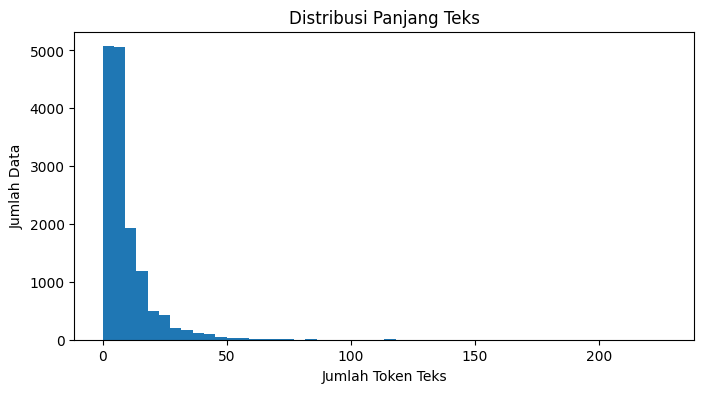

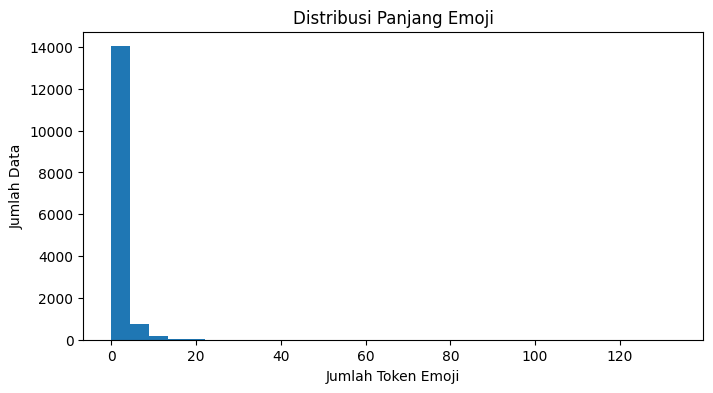

In [19]:
# ============================================================
# 5. ANALISIS PANJANG TEKS DAN EMOJI
# ============================================================

df_model['text_len'] = df_model['text_only'].apply(lambda x: len(str(x).split()))
df_model['emoji_len'] = df_model['emoji_tokens'].apply(len)

print("Statistik panjang teks:")
print(df_model['text_len'].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]))

print("\nStatistik panjang emoji:")
print(df_model['emoji_len'].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]))

plt.figure(figsize=(8, 4))
plt.hist(df_model['text_len'], bins=50)
plt.title("Distribusi Panjang Teks")
plt.xlabel("Jumlah Token Teks")
plt.ylabel("Jumlah Data")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_model['emoji_len'], bins=30)
plt.title("Distribusi Panjang Emoji")
plt.xlabel("Jumlah Token Emoji")
plt.ylabel("Jumlah Data")
plt.show()

In [20]:
# ============================================================
# 5.1 PENENTUAN PANJANG SEQUENCE
# ============================================================

MAX_TEXT_LEN = 50
MAX_EMOJI_LEN = 10

print("MAX_TEXT_LEN :", MAX_TEXT_LEN)
print("MAX_EMOJI_LEN:", MAX_EMOJI_LEN)

MAX_TEXT_LEN : 50
MAX_EMOJI_LEN: 10


# 6. Split Data Train, Validation, dan Test Tanpa Data Leakage

Pada V5, data dibagi terlebih dahulu sebelum proses tokenisasi, pelatihan Word2Vec, dan penanganan ketidakseimbangan kelas.

Hal ini dilakukan untuk mencegah data leakage. Jika tokenizer, Word2Vec, atau oversampling dilakukan sebelum split, maka informasi dari data validation/test dapat ikut terbaca saat proses training.

Strategi split yang digunakan:

- Train: 70%
- Validation: 10%
- Test: 20%

Split dilakukan secara stratified agar proporsi label pada train, validation, dan test tetap seimbang mengikuti distribusi asli dataset.

In [21]:
# ============================================================
# 6. SPLIT DATA TANPA LEAKAGE
# ============================================================

label_encoder = LabelEncoder()
df_model['label_encoded'] = label_encoder.fit_transform(df_model['label'])

print("Mapping label:")
for label, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label} -> {encoded}")

# Split 80% trainval dan 20% test
trainval_df, test_df = train_test_split(
    df_model,
    test_size=0.20,
    random_state=SEED,
    stratify=df_model['label_encoded']
)

# Dari trainval 80%, ambil 12.5% sebagai validation
# 12.5% dari 80% = 10% total data
train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.125,
    random_state=SEED,
    stratify=trainval_df['label_encoded']
)

print("\nJumlah data:")
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\nDistribusi label train:")
print(train_df['label'].value_counts())

print("\nDistribusi label validation:")
print(val_df['label'].value_counts())

print("\nDistribusi label test:")
print(test_df['label'].value_counts())

print("\nPersentase label test:")
print((test_df['label'].value_counts(normalize=True) * 100).round(2))

Mapping label:
negatif -> 0
netral -> 1
positif -> 2

Jumlah data:
Train      : 10507
Validation : 1502
Test       : 3003

Distribusi label train:
label
positif    4887
negatif    4363
netral     1257
Name: count, dtype: int64

Distribusi label validation:
label
positif    699
negatif    623
netral     180
Name: count, dtype: int64

Distribusi label test:
label
positif    1397
negatif    1247
netral      359
Name: count, dtype: int64

Persentase label test:
label
positif    46.52
negatif    41.53
netral     11.95
Name: proportion, dtype: float64


# 7. Class Weight

Dataset memiliki distribusi kelas yang tidak seimbang, terutama pada kelas netral yang jumlahnya jauh lebih sedikit dibandingkan kelas positif dan negatif.

Untuk menangani ketidakseimbangan kelas tanpa menyebabkan data leakage, digunakan `class_weight`. Dengan cara ini, kelas minoritas diberi bobot lebih besar saat proses training, sementara data validation dan test tetap mengikuti distribusi asli dataset.

In [22]:
# ============================================================
# 7. CLASS WEIGHT
# ============================================================

classes = np.unique(train_df['label_encoded'])

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label_encoded']
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
for class_id, weight in class_weights.items():
    label_name = label_encoder.inverse_transform([class_id])[0]
    print(f"{class_id} ({label_name}) -> {weight:.4f}")

NUM_CLASSES = len(label_encoder.classes_)

y_train = to_categorical(train_df['label_encoded'], num_classes=NUM_CLASSES)
y_val = to_categorical(val_df['label_encoded'], num_classes=NUM_CLASSES)
y_test = to_categorical(test_df['label_encoded'], num_classes=NUM_CLASSES)

print("\nJumlah kelas:", NUM_CLASSES)
print("Shape y_train:", y_train.shape)
print("Shape y_val  :", y_val.shape)
print("Shape y_test :", y_test.shape)

Class weights:
0 (negatif) -> 0.8027
1 (netral) -> 2.7863
2 (positif) -> 0.7167

Jumlah kelas: 3
Shape y_train: (10507, 3)
Shape y_val  : (1502, 3)
Shape y_test : (3003, 3)


# 8. Persiapan Input Teks dan Emoji

Pada tahap ini, data train, validation, dan test dipisahkan menjadi dua input:

1. Input teks (`text_only`) untuk jalur Word2Vec.
2. Input emoji (`emoji_tokens`) untuk jalur emoji embedding.

Karena tokenizer Keras menerima input berupa string, daftar token emoji digabung menjadi satu string dengan spasi antar emoji.

In [23]:
# ============================================================
# 8. PERSIAPAN INPUT TEKS DAN EMOJI
# ============================================================

X_train_text = train_df['text_only'].astype(str).values
X_val_text = val_df['text_only'].astype(str).values
X_test_text = test_df['text_only'].astype(str).values

X_train_emoji = train_df['emoji_tokens'].apply(lambda tokens: " ".join(tokens)).astype(str).values
X_val_emoji = val_df['emoji_tokens'].apply(lambda tokens: " ".join(tokens)).astype(str).values
X_test_emoji = test_df['emoji_tokens'].apply(lambda tokens: " ".join(tokens)).astype(str).values

print("Contoh input teks:")
print(X_train_text[:5])

print("\nContoh input emoji:")
print(X_train_emoji[:5])

print("\nShape input:")
print("X_train_text :", X_train_text.shape)
print("X_val_text   :", X_val_text.shape)
print("X_test_text  :", X_test_text.shape)

print("X_train_emoji:", X_train_emoji.shape)
print("X_val_emoji  :", X_val_emoji.shape)
print("X_test_emoji :", X_test_emoji.shape)

Contoh input teks:
['saya sebagai cowo kalau deketin alea pasti minder sama bapaknya kalah dalam segala hal itu tidak enak'
 'seketika saya ingin jadi ayahnya'
 'tidak tersa air mata mnetes air mata ini sukses selalu ya dek'
 'kangen ovj tempo dlu' 'kan agus bisa lihat coba aku pake baju apa']

Contoh input emoji:
['<wajah_tersenyum_mulut_terbuka_dan_keringat_dingin> <wajah_tersenyum_mulut_terbuka_dan_keringat_dingin> <wajah_tersenyum_mulut_terbuka_dan_keringat_dingin> <wajah_tersenyum_mulut_terbuka_dan_keringat_dingin>'
 '<wajah_menangis_gembira>'
 '<wajah_menangis> <wajah_menangis> <wajah_menangis> <wajah_menangis>'
 '<wajah_menangis>'
 '<wajah_memutar_mata> <wajah_memutar_mata> <wajah_memutar_mata>']

Shape input:
X_train_text : (10507,)
X_val_text   : (1502,)
X_test_text  : (3003,)
X_train_emoji: (10507,)
X_val_emoji  : (1502,)
X_test_emoji : (3003,)


# 9. Tokenisasi Teks dan Emoji

Pada tahap ini, teks dan emoji diubah menjadi sequence numerik agar dapat diproses oleh model deep learning.

Tokenizer hanya di-fit menggunakan data train untuk mencegah data leakage. Data validation dan test hanya ditransformasi menggunakan tokenizer yang sudah dibuat dari data train.

Terdapat dua tokenizer:

1. `text_tokenizer` untuk input teks.
2. `emoji_tokenizer` untuk input emoji.

Sequence kemudian dipadding agar memiliki panjang yang seragam:

- `MAX_TEXT_LEN = 50`
- `MAX_EMOJI_LEN = 10`

In [24]:
# ============================================================
# 9. TOKENISASI TEKS DAN EMOJI
# ============================================================

MAX_TEXT_VOCAB = 20000
MAX_EMOJI_VOCAB = 500

# Tokenizer teks
text_tokenizer = Tokenizer(
    num_words=MAX_TEXT_VOCAB,
    oov_token='<OOV>',
    filters='',
    lower=False
)

text_tokenizer.fit_on_texts(X_train_text)

X_train_text_seq = text_tokenizer.texts_to_sequences(X_train_text)
X_val_text_seq = text_tokenizer.texts_to_sequences(X_val_text)
X_test_text_seq = text_tokenizer.texts_to_sequences(X_test_text)

X_train_text_pad = pad_sequences(
    X_train_text_seq,
    maxlen=MAX_TEXT_LEN,
    padding='post',
    truncating='post'
)

X_val_text_pad = pad_sequences(
    X_val_text_seq,
    maxlen=MAX_TEXT_LEN,
    padding='post',
    truncating='post'
)

X_test_text_pad = pad_sequences(
    X_test_text_seq,
    maxlen=MAX_TEXT_LEN,
    padding='post',
    truncating='post'
)


# Tokenizer emoji
emoji_tokenizer = Tokenizer(
    num_words=MAX_EMOJI_VOCAB,
    oov_token='<OOV>',
    filters='',
    lower=False
)

emoji_tokenizer.fit_on_texts(X_train_emoji)

X_train_emoji_seq = emoji_tokenizer.texts_to_sequences(X_train_emoji)
X_val_emoji_seq = emoji_tokenizer.texts_to_sequences(X_val_emoji)
X_test_emoji_seq = emoji_tokenizer.texts_to_sequences(X_test_emoji)

X_train_emoji_pad = pad_sequences(
    X_train_emoji_seq,
    maxlen=MAX_EMOJI_LEN,
    padding='post',
    truncating='post'
)

X_val_emoji_pad = pad_sequences(
    X_val_emoji_seq,
    maxlen=MAX_EMOJI_LEN,
    padding='post',
    truncating='post'
)

X_test_emoji_pad = pad_sequences(
    X_test_emoji_seq,
    maxlen=MAX_EMOJI_LEN,
    padding='post',
    truncating='post'
)


TEXT_VOCAB_SIZE = min(MAX_TEXT_VOCAB, len(text_tokenizer.word_index) + 1)
EMOJI_VOCAB_SIZE = min(MAX_EMOJI_VOCAB, len(emoji_tokenizer.word_index) + 1)

print("Text vocab size :", TEXT_VOCAB_SIZE)
print("Emoji vocab size:", EMOJI_VOCAB_SIZE)

print("\nShape text padded:")
print("Train:", X_train_text_pad.shape)
print("Val  :", X_val_text_pad.shape)
print("Test :", X_test_text_pad.shape)

print("\nShape emoji padded:")
print("Train:", X_train_emoji_pad.shape)
print("Val  :", X_val_emoji_pad.shape)
print("Test :", X_test_emoji_pad.shape)

print("\nContoh sequence teks:")
print(X_train_text_pad[:2])

print("\nContoh sequence emoji:")
print(X_train_emoji_pad[:2])

Text vocab size : 15483
Emoji vocab size: 124

Shape text padded:
Train: (10507, 50)
Val  : (1502, 50)
Test : (3003, 50)

Shape emoji padded:
Train: (10507, 10)
Val  : (1502, 10)
Test : (3003, 10)

Contoh sequence teks:
[[   8  390 1182   15 1609 3078   80 1815   13  712  459   99  359  251
    16    4   57    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]
 [1610    8   68   17 1423    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0]]

Contoh sequence emoji:
[[7 7 7 7 0 0 0 0 0 0]
 [2 0 0 0 0 0 0 0 0 0]]


# 10. Word2Vec Embedding untuk Teks

Pada tahap ini, representasi embedding untuk teks dibuat menggunakan Word2Vec.

Word2Vec hanya dilatih menggunakan data train agar tidak terjadi data leakage dari data validation maupun test. Hasil Word2Vec kemudian digunakan sebagai bobot awal pada embedding layer teks.

Embedding teks bersifat `trainable=True`, sehingga bobot awal dari Word2Vec masih dapat disesuaikan kembali selama training model.

In [25]:
# ============================================================
# 10. WORD2VEC TEXT EMBEDDING
# ============================================================

TEXT_EMBEDDING_DIM = 200

# Token kalimat train untuk Word2Vec
sentences_text_train = [str(text).split() for text in X_train_text]

w2v_text = Word2Vec(
    sentences=sentences_text_train,
    vector_size=TEXT_EMBEDDING_DIM,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    seed=SEED,
    epochs=20
)

embedding_matrix_text = np.zeros((TEXT_VOCAB_SIZE, TEXT_EMBEDDING_DIM))

found_words = 0
missing_words = 0

for word, idx in text_tokenizer.word_index.items():
    if idx >= TEXT_VOCAB_SIZE:
        continue

    if word in w2v_text.wv:
        embedding_matrix_text[idx] = w2v_text.wv[word]
        found_words += 1
    else:
        embedding_matrix_text[idx] = np.random.normal(0, 0.05, TEXT_EMBEDDING_DIM)
        missing_words += 1

print("Word2Vec text selesai.")
print("Text embedding dim     :", TEXT_EMBEDDING_DIM)
print("Text vocab size        :", TEXT_VOCAB_SIZE)
print("Embedding matrix shape :", embedding_matrix_text.shape)
print("Found words            :", found_words)
print("Missing words          :", missing_words)

Word2Vec text selesai.
Text embedding dim     : 200
Text vocab size        : 15483
Embedding matrix shape : (15483, 200)
Found words            : 15481
Missing words          : 1


# 11. Shared Text-Emoji Embedding Layer

Tahap ini membuat fungsi embedding bersama yang akan digunakan oleh ketiga model:

1. CNN Standalone
2. BiLSTM Standalone
3. Hybrid CNN-BiLSTM

Jalur teks menggunakan Word2Vec embedding sebagai bobot awal. Embedding teks dibuat `trainable=True` agar representasi kata dapat menyesuaikan dengan konteks dataset sentimen.

Jalur emoji menggunakan trainable emoji embedding. Emoji tidak dimasukkan ke Word2Vec, tetapi dipelajari melalui embedding layer tersendiri berdasarkan token emoji.

Karena dimensi embedding teks dan emoji berbeda, embedding emoji diproyeksikan terlebih dahulu agar dimensinya sama dengan embedding teks. Setelah itu, sequence teks dan sequence emoji digabung menggunakan Concatenate.

In [26]:
# ============================================================
# 11. SHARED TEXT-EMOJI EMBEDDING LAYER
# ============================================================

EMOJI_EMBEDDING_DIM = 64

def build_shared_text_emoji_embedding():
    """
    Membuat input dan embedding gabungan untuk teks dan emoji.

    Output:
    - text_input
    - emoji_input
    - merged_sequence
    """

    # Input teks dan emoji
    text_input = Input(
        shape=(MAX_TEXT_LEN,),
        name='text_input'
    )

    emoji_input = Input(
        shape=(MAX_EMOJI_LEN,),
        name='emoji_input'
    )

    # Text embedding: Word2Vec sebagai bobot awal, lalu fine-tuned
    text_embedding = Embedding(
        input_dim=TEXT_VOCAB_SIZE,
        output_dim=TEXT_EMBEDDING_DIM,
        weights=[embedding_matrix_text],
        trainable=True,
        name='word2vec_text_embedding_trainable'
    )(text_input)

    text_embedding = SpatialDropout1D(
        0.20,
        name='text_spatial_dropout'
    )(text_embedding)

    # Emoji embedding: trainable embedding dari token emoji
    emoji_embedding = Embedding(
        input_dim=EMOJI_VOCAB_SIZE,
        output_dim=EMOJI_EMBEDDING_DIM,
        trainable=True,
        name='trainable_emoji_embedding'
    )(emoji_input)

    emoji_embedding = SpatialDropout1D(
        0.10,
        name='emoji_spatial_dropout'
    )(emoji_embedding)

    # Proyeksi emoji embedding agar dimensinya sama dengan text embedding
    emoji_projection = Dense(
        TEXT_EMBEDDING_DIM,
        activation='relu',
        name='emoji_projection_to_text_dim'
    )(emoji_embedding)

    # Gabungkan sequence teks dan emoji
    # Shape: (MAX_TEXT_LEN + MAX_EMOJI_LEN, TEXT_EMBEDDING_DIM)
    merged_sequence = Concatenate(
        axis=1,
        name='concatenate_text_emoji_sequence'
    )([
        text_embedding,
        emoji_projection
    ])

    return text_input, emoji_input, merged_sequence


# Tes fungsi shared embedding
test_text_input, test_emoji_input, test_merged_sequence = build_shared_text_emoji_embedding()

print("Shared embedding berhasil dibuat.")
print("Text input shape       :", test_text_input.shape)
print("Emoji input shape      :", test_emoji_input.shape)
print("Merged sequence shape  :", test_merged_sequence.shape)

Shared embedding berhasil dibuat.
Text input shape       : (None, 50)
Emoji input shape      : (None, 10)
Merged sequence shape  : (None, 60, 200)


# 12. Callback Training

Tahap ini membuat fungsi callback yang akan digunakan pada semua model.

Callback yang digunakan:

1. `EarlyStopping`, untuk menghentikan training jika validation loss tidak membaik.
2. `ReduceLROnPlateau`, untuk menurunkan learning rate jika validation loss stagnan.
3. `ModelCheckpoint`, untuk menyimpan model terbaik berdasarkan validation accuracy.

Callback dibuat dalam bentuk fungsi agar setiap model memiliki file checkpoint berbeda.

In [27]:
# ============================================================
# 12. CALLBACK TRAINING
# ============================================================

def get_callbacks(model_name):
    """
    Membuat callback untuk training model.
    """

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),

        ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]

    return callbacks

print("Callback function siap digunakan.")

Callback function siap digunakan.


# 13. Fungsi Evaluasi Model

Tahap ini membuat fungsi evaluasi yang digunakan untuk semua model.

Metrik evaluasi yang digunakan:

1. Accuracy
2. Precision Macro
3. Recall Macro
4. F1 Macro
5. Classification Report
6. Confusion Matrix

Macro average digunakan karena dataset memiliki distribusi kelas yang tidak seimbang, terutama pada kelas netral.

In [28]:
# ============================================================
# 13. FUNGSI EVALUASI MODEL
# ============================================================

results = []

def evaluate_model(model, model_name):
    """
    Evaluasi model pada test set.
    """

    print("=" * 70)
    print(f"EVALUASI MODEL: {model_name}")
    print("=" * 70)

    y_pred_prob = model.predict(
        [X_test_text_pad, X_test_emoji_pad],
        verbose=0
    )

    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    acc = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"Accuracy        : {acc:.4f}")
    print(f"Precision Macro : {precision_macro:.4f}")
    print(f"Recall Macro    : {recall_macro:.4f}")
    print(f"F1 Macro        : {f1_macro:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    result = {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro
    }

    results.append(result)

    return result

In [45]:
# ============================================================
# EVALUASI DETAIL UNTUK MASING-MASING MODEL
# ============================================================

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)

def evaluasi_detail_model(model, nama_model):
    print(f"\nMenghitung prediksi model {nama_model} pada data uji...")

    y_pred_prob = model.predict(
        [X_test_text_pad, X_test_emoji_pad],
        verbose=0
    )

    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    nama_kelas = list(label_encoder.classes_)

    print(f"\n=================== CLASSIFICATION REPORT ({nama_model.upper()}) ===================")
    print(classification_report(
        y_true,
        y_pred,
        target_names=nama_kelas,
        digits=4,
        zero_division=0
    ))
    print("======================================================================================\n")

    print(f"===================== RINGKASAN METRIK GLOBAL ({nama_model.upper()}) =====================")

    akurasi_total = accuracy_score(y_true, y_pred)

    presisi_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='macro',
        zero_division=0
    )

    presisi_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    print(f"Akurasi Global (Accuracy)        : {akurasi_total:.4f} ({akurasi_total*100:.2f}%)")
    print(f"Rata-rata Presisi (Macro Prec)   : {presisi_macro:.4f}")
    print(f"Rata-rata Recall (Macro Recall)  : {recall_macro:.4f}")
    print(f"Rata-rata F1-Score (Macro F1)    : {f1_macro:.4f}")
    print("--------------------------------------------------------------------------------------")
    print(f"Weighted Precision               : {presisi_weighted:.4f}")
    print(f"Weighted Recall                  : {recall_weighted:.4f}")
    print(f"Weighted F1-Score                : {f1_weighted:.4f}")
    print("======================================================================================\n")

    return {
        'model': nama_model,
        'accuracy': akurasi_total,
        'precision_macro': presisi_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': presisi_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted
    }

# 14. Fungsi Visualisasi History Training

Tahap ini membuat fungsi untuk menampilkan grafik training history dari setiap model.

Grafik yang ditampilkan:

1. Training Accuracy vs Validation Accuracy
2. Training Loss vs Validation Loss

Visualisasi ini digunakan untuk melihat apakah model mengalami overfitting, underfitting, atau training yang stabil.

In [29]:
# ============================================================
# 14. FUNGSI VISUALISASI HISTORY TRAINING
# ============================================================

def plot_training_history(history, model_name):
    """
    Menampilkan grafik accuracy dan loss dari history training.
    """

    # Accuracy plot
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy - {model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss plot
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss - {model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


print("Fungsi plot training history siap digunakan.")

Fungsi plot training history siap digunakan.


# 15. Model 1 — CNN Standalone

Model pertama adalah CNN standalone.

Model ini menggunakan input gabungan dari embedding teks dan emoji. Setelah embedding teks dan emoji digabung, sequence diproses menggunakan beberapa Conv1D dengan ukuran kernel berbeda.

CNN digunakan sebagai baseline karena mampu menangkap pola lokal pada teks, seperti kombinasi kata pendek atau kombinasi teks-emoji yang memiliki makna sentimen.

In [30]:
# ============================================================
# 15. MODEL 1 - CNN STANDALONE
# ============================================================

def build_cnn_model():
    """
    Membangun model CNN standalone dengan input gabungan text + emoji.
    """

    text_input, emoji_input, merged_sequence = build_shared_text_emoji_embedding()

    # CNN multi-kernel untuk menangkap pola lokal dengan panjang berbeda
    conv_3 = Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu',
        padding='same',
        name='cnn_conv_kernel_3'
    )(merged_sequence)

    conv_4 = Conv1D(
        filters=128,
        kernel_size=4,
        activation='relu',
        padding='same',
        name='cnn_conv_kernel_4'
    )(merged_sequence)

    conv_5 = Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu',
        padding='same',
        name='cnn_conv_kernel_5'
    )(merged_sequence)

    # Pooling masing-masing kernel
    pool_3 = GlobalMaxPooling1D(name='cnn_global_max_pool_3')(conv_3)
    pool_4 = GlobalMaxPooling1D(name='cnn_global_max_pool_4')(conv_4)
    pool_5 = GlobalMaxPooling1D(name='cnn_global_max_pool_5')(conv_5)

    # Gabungkan hasil CNN multi-kernel
    x = Concatenate(name='cnn_multi_kernel_concatenate')([pool_3, pool_4, pool_5])

    x = Dense(
        128,
        activation='relu',
        kernel_regularizer=l2(1e-4),
        name='cnn_dense_128'
    )(x)

    x = BatchNormalization(name='cnn_batch_norm')(x)
    x = Dropout(0.35, name='cnn_dropout')(x)

    output = Dense(
        NUM_CLASSES,
        activation='softmax',
        name='cnn_output_softmax'
    )(x)

    model = Model(
        inputs=[text_input, emoji_input],
        outputs=output,
        name='CNN_Standalone_Text_Emoji'
    )

    model.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


cnn_model = build_cnn_model()
cnn_model.summary()

Model: "CNN_Standalone_Text_Emoji"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ emoji_input         │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trainable_emoji_em… │ (None, 10, 64)    │      7,936 │ emoji_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word2vec_text_embe… │ (None, 50, 200)   │  3,096,600 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_spatial_drop… │ (None, 10, 64)    │          0 │ trainable_emoji_… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_spatial_dropo… │ (None, 50, 200)   │          0 │ word2vec_text_em… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_projection_t… │ (None, 10, 200)   │     13,000 │ emoji_spatial_dr… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_text_e… │ (None, 60, 200)   │          0 │ text_spatial_dro… │
│ (Concatenate)       │                   │            │ emoji_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_kernel_3   │ (None, 60, 128)   │     76,928 │ concatenate_text… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_kernel_4   │ (None, 60, 128)   │    102,528 │ concatenate_text… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_kernel_5   │ (None, 60, 128)   │    128,128 │ concatenate_text… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_global_max_poo… │ (None, 128)       │          0 │ cnn_conv_kernel_… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_global_max_poo… │ (None, 128)       │          0 │ cnn_conv_kernel_… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_global_max_poo… │ (None, 128)       │          0 │ cnn_conv_kernel_… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_multi_kernel_c… │ (None, 384)       │          0 │ cnn_global_max_p… │
│ (Concatenate)       │                   │            │ cnn_global_max_p… │
│                     │                   │            │ cnn_global_max_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dense_128       │ (None, 128)       │     49,280 │ cnn_multi_kernel… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,475,299 (13.26 MB)

 Trainable params: 3,475,043 (13.26 MB)

 Non-trainable params: 256 (1.00 KB)

# 16. Training Model 1 — CNN Standalone

Pada tahap ini, model CNN standalone dilatih menggunakan data train dan divalidasi menggunakan data validation.

Training menggunakan `class_weight` untuk membantu model memperhatikan kelas minoritas, khususnya kelas netral.

Model terbaik disimpan berdasarkan validation accuracy, sedangkan EarlyStopping menggunakan validation loss untuk menghindari overfitting.

In [32]:
# ============================================================
# 16. TRAINING MODEL 1 - CNN STANDALONE
# ============================================================

EPOCHS = 50
BATCH_SIZE = 64

start_time = time.time()

history_cnn = cnn_model.fit(
    [X_train_text_pad, X_train_emoji_pad],
    y_train,
    validation_data=(
        [X_val_text_pad, X_val_emoji_pad],
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=get_callbacks('cnn_standalone_text_emoji'),
    verbose=1
)

end_time = time.time()
training_time_cnn = end_time - start_time

print(f"\nWaktu training CNN: {training_time_cnn/60:.2f} menit")

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8852 - loss: 0.2984
Epoch 1: val_accuracy improved from None to 0.75632, saving model to best_cnn_standalone_text_emoji.keras

Epoch 1: finished saving model to best_cnn_standalone_text_emoji.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 66s 400ms/step - accuracy: 0.8914 - loss: 0.2817 - val_accuracy: 0.7563 - val_loss: 0.6315 - learning_rate: 7.5000e-05
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9003 - loss: 0.2634
Epoch 2: val_accuracy did not improve from 0.75632
165/165 ━━━━━━━━━━━━━━━━━━━━ 60s 267ms/step - accuracy: 0.9088 - loss: 0.2502 - val_accuracy: 0.7503 - val_loss: 0.6488 - learning_rate: 7.5000e-05
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9112 - loss: 0.2357
Epoch 3: val_accuracy improved from 0.75632 to 0.75899, saving model to best_cnn_standalone_text_emoji.keras

Epoch 3: finished saving model to best_cnn_standalone_text_emoji.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 5

## Catatan

Training CNN sebelumnya tidak digunakan sebagai hasil final karena cell training sempat dijalankan ulang sehingga model melanjutkan training dari bobot sebelumnya. Untuk menjaga perbandingan eksperimen tetap fair, model CNN dibangun ulang dari awal dan dilatih kembali dengan checkpoint baru.

In [33]:
# ============================================================
# RESET DAN BUILD ULANG CNN CLEAN
# ============================================================

tf.keras.backend.clear_session()

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

cnn_model = build_cnn_model()
cnn_model.summary()

Model: "CNN_Standalone_Text_Emoji"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ emoji_input         │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trainable_emoji_em… │ (None, 10, 64)    │      7,936 │ emoji_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word2vec_text_embe… │ (None, 50, 200)   │  3,096,600 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_spatial_drop… │ (None, 10, 64)    │          0 │ trainable_emoji_… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_spatial_dropo… │ (None, 50, 200)   │          0 │ word2vec_text_em… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_projection_t… │ (None, 10, 200)   │     13,000 │ emoji_spatial_dr… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_text_e… │ (None, 60, 200)   │          0 │ text_spatial_dro… │
│ (Concatenate)       │                   │            │ emoji_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_kernel_3   │ (None, 60, 128)   │     76,928 │ concatenate_text… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_kernel_4   │ (None, 60, 128)   │    102,528 │ concatenate_text… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_kernel_5   │ (None, 60, 128)   │    128,128 │ concatenate_text… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_global_max_poo… │ (None, 128)       │          0 │ cnn_conv_kernel_… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_global_max_poo… │ (None, 128)       │          0 │ cnn_conv_kernel_… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_global_max_poo… │ (None, 128)       │          0 │ cnn_conv_kernel_… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_multi_kernel_c… │ (None, 384)       │          0 │ cnn_global_max_p… │
│ (Concatenate)       │                   │            │ cnn_global_max_p… │
│                     │                   │            │ cnn_global_max_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dense_128       │ (None, 128)       │     49,280 │ cnn_multi_kernel… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,475,299 (13.26 MB)

 Trainable params: 3,475,043 (13.26 MB)

 Non-trainable params: 256 (1.00 KB)

In [34]:
# ============================================================
# TRAINING MODEL 1 - CNN STANDALONE CLEAN RUN
# ============================================================

EPOCHS = 50
BATCH_SIZE = 64

start_time = time.time()

history_cnn = cnn_model.fit(
    [X_train_text_pad, X_train_emoji_pad],
    y_train,
    validation_data=(
        [X_val_text_pad, X_val_emoji_pad],
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=get_callbacks('v5_cnn_clean'),
    verbose=1
)

end_time = time.time()
training_time_cnn = end_time - start_time

print(f"\nWaktu training CNN clean: {training_time_cnn/60:.2f} menit")

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.4247 - loss: 1.2318
Epoch 1: val_accuracy improved from None to 0.53262, saving model to best_v5_cnn_clean.keras

Epoch 1: finished saving model to best_v5_cnn_clean.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 56s 286ms/step - accuracy: 0.4589 - loss: 1.1263 - val_accuracy: 0.5326 - val_loss: 0.9664 - learning_rate: 3.0000e-04
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.5183 - loss: 0.9839
Epoch 2: val_accuracy did not improve from 0.53262
165/165 ━━━━━━━━━━━━━━━━━━━━ 79s 267ms/step - accuracy: 0.5271 - loss: 0.9657 - val_accuracy: 0.4441 - val_loss: 1.0986 - learning_rate: 3.0000e-04
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.5908 - loss: 0.8434
Epoch 3: val_accuracy improved from 0.53262 to 0.70439, saving model to best_v5_cnn_clean.keras

Epoch 3: finished saving model to best_v5_cnn_clean.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 82s 270ms/step - accuracy: 0.6414 - loss: 0.7819 - va

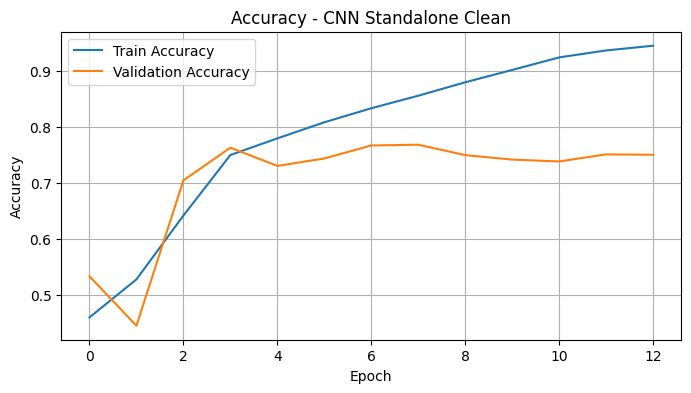

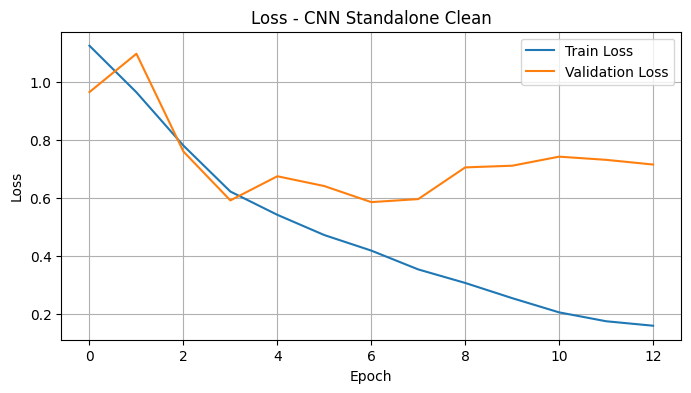

EVALUASI MODEL: CNN Standalone Clean
Accuracy        : 0.7486
Precision Macro : 0.6802
Recall Macro    : 0.6958
F1 Macro        : 0.6858

Classification Report:
              precision    recall  f1-score   support

     negatif       0.83      0.77      0.80      1247
      netral       0.43      0.53      0.47       359
     positif       0.79      0.78      0.79      1397

    accuracy                           0.75      3003
   macro avg       0.68      0.70      0.69      3003
weighted avg       0.76      0.75      0.75      3003



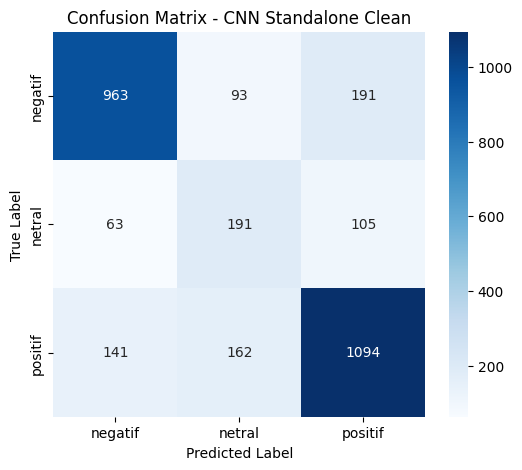

{'model': 'CNN Standalone Clean',
 'accuracy': 0.7485847485847485,
 'precision_macro': 0.6801647609483396,
 'recall_macro': 0.6957978304952933,
 'f1_macro': 0.6858178720694647}

In [35]:
# ============================================================
# 17. PLOT DAN EVALUASI CNN CLEAN
# ============================================================

plot_training_history(history_cnn, "CNN Standalone Clean")

cnn_result = evaluate_model(cnn_model, "CNN Standalone Clean")

cnn_result

In [46]:
# ============================================================
# EVALUASI MODEL CNN
# ============================================================

eval_cnn_detail = evaluasi_detail_model(
    cnn_model,
    "CNN Standalone"
)


Menghitung prediksi model CNN Standalone pada data uji...

=================== CLASSIFICATION REPORT (CNN STANDALONE) ===================
              precision    recall  f1-score   support

     negatif     0.8252    0.7723    0.7978      1247
      netral     0.4283    0.5320    0.4745       359
     positif     0.7871    0.7831    0.7851      1397

    accuracy                         0.7486      3003
   macro avg     0.6802    0.6958    0.6858      3003
weighted avg     0.7600    0.7486    0.7533      3003


===================== RINGKASAN METRIK GLOBAL (CNN STANDALONE) =====================
Akurasi Global (Accuracy)        : 0.7486 (74.86%)
Rata-rata Presisi (Macro Prec)   : 0.6802
Rata-rata Recall (Macro Recall)  : 0.6958
Rata-rata F1-Score (Macro F1)    : 0.6858
--------------------------------------------------------------------------------------
Weighted Precision               : 0.7600
Weighted Recall                  : 0.7486
Weighted F1-Score                : 0.7533



# 18. Model 2 — BiLSTM Standalone

Model kedua adalah BiLSTM standalone.

Model ini menggunakan input gabungan dari embedding teks dan emoji, sama seperti model CNN. Perbedaannya, setelah embedding teks dan emoji digabung, sequence diproses menggunakan Bidirectional LSTM.

BiLSTM digunakan karena mampu membaca urutan teks dari dua arah, yaitu dari awal ke akhir dan dari akhir ke awal, sehingga dapat menangkap konteks yang lebih panjang dibanding CNN.

In [36]:
# ============================================================
# 18. MODEL 2 - BILSTM STANDALONE
# ============================================================

def build_bilstm_model():
    """
    Membangun model BiLSTM standalone dengan input gabungan text + emoji.
    """

    text_input, emoji_input, merged_sequence = build_shared_text_emoji_embedding()

    x = Bidirectional(
        LSTM(
            64,
            return_sequences=True,
            dropout=0.25,
            recurrent_dropout=0.0
        ),
        name='bilstm_layer'
    )(merged_sequence)

    x = GlobalMaxPooling1D(name='bilstm_global_max_pool')(x)

    x = Dense(
        128,
        activation='relu',
        kernel_regularizer=l2(1e-4),
        name='bilstm_dense_128'
    )(x)

    x = BatchNormalization(name='bilstm_batch_norm')(x)
    x = Dropout(0.35, name='bilstm_dropout')(x)

    output = Dense(
        NUM_CLASSES,
        activation='softmax',
        name='bilstm_output_softmax'
    )(x)

    model = Model(
        inputs=[text_input, emoji_input],
        outputs=output,
        name='BiLSTM_Standalone_Text_Emoji'
    )

    model.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


tf.keras.backend.clear_session()

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

bilstm_model = build_bilstm_model()
bilstm_model.summary()

Model: "BiLSTM_Standalone_Text_Emoji"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ emoji_input         │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trainable_emoji_em… │ (None, 10, 64)    │      7,936 │ emoji_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word2vec_text_embe… │ (None, 50, 200)   │  3,096,600 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_spatial_drop… │ (None, 10, 64)    │          0 │ trainable_emoji_… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_spatial_dropo… │ (None, 50, 200)   │          0 │ word2vec_text_em… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_projection_t… │ (None, 10, 200)   │     13,000 │ emoji_spatial_dr… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_text_e… │ (None, 60, 200)   │          0 │ text_spatial_dro… │
│ (Concatenate)       │                   │            │ emoji_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_layer        │ (None, 60, 128)   │    135,680 │ concatenate_text… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_global_max_… │ (None, 128)       │          0 │ bilstm_layer[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_dense_128    │ (None, 128)       │     16,512 │ bilstm_global_ma… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_batch_norm   │ (None, 128)       │        512 │ bilstm_dense_128… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_dropout      │ (None, 128)       │          0 │ bilstm_batch_nor… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_output_soft… │ (None, 3)         │        387 │ bilstm_dropout[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,270,627 (12.48 MB)

 Trainable params: 3,270,371 (12.48 MB)

 Non-trainable params: 256 (1.00 KB)

In [37]:
# ============================================================
# 19. TRAINING MODEL 2 - BILSTM STANDALONE CLEAN RUN
# ============================================================

EPOCHS = 50
BATCH_SIZE = 64

start_time = time.time()

history_bilstm = bilstm_model.fit(
    [X_train_text_pad, X_train_emoji_pad],
    y_train,
    validation_data=(
        [X_val_text_pad, X_val_emoji_pad],
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=get_callbacks('v5_bilstm_clean'),
    verbose=1
)

end_time = time.time()
training_time_bilstm = end_time - start_time

print(f"\nWaktu training BiLSTM clean: {training_time_bilstm/60:.2f} menit")

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.3939 - loss: 1.2161
Epoch 1: val_accuracy improved from None to 0.63182, saving model to best_v5_bilstm_clean.keras

Epoch 1: finished saving model to best_v5_bilstm_clean.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 57s 262ms/step - accuracy: 0.4307 - loss: 1.1268 - val_accuracy: 0.6318 - val_loss: 1.0167 - learning_rate: 3.0000e-04
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.5080 - loss: 0.9855
Epoch 2: val_accuracy improved from 0.63182 to 0.73036, saving model to best_v5_bilstm_clean.keras

Epoch 2: finished saving model to best_v5_bilstm_clean.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 81s 261ms/step - accuracy: 0.5553 - loss: 0.9210 - val_accuracy: 0.7304 - val_loss: 0.8047 - learning_rate: 3.0000e-04
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.6567 - loss: 0.8173
Epoch 3: val_accuracy did not improve from 0.73036
165/165 ━━━━━━━━━━━━━━━━━━━━ 82s 265ms/step - accuracy: 0.6726 - loss:

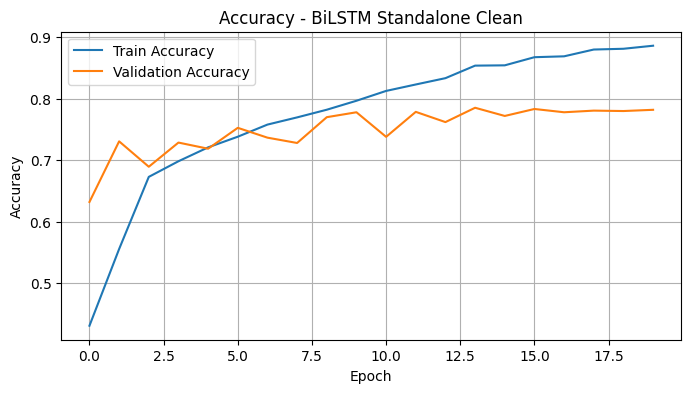

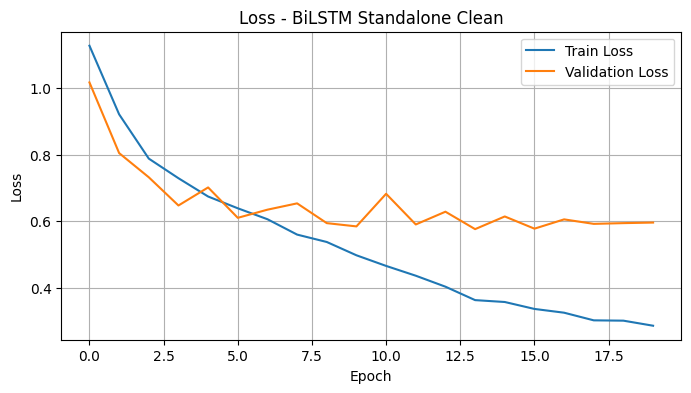

EVALUASI MODEL: BiLSTM Standalone Clean
Accuracy        : 0.7582
Precision Macro : 0.6975
Recall Macro    : 0.7295
F1 Macro        : 0.7074

Classification Report:
              precision    recall  f1-score   support

     negatif       0.82      0.77      0.79      1247
      netral       0.45      0.64      0.53       359
     positif       0.82      0.78      0.80      1397

    accuracy                           0.76      3003
   macro avg       0.70      0.73      0.71      3003
weighted avg       0.78      0.76      0.77      3003



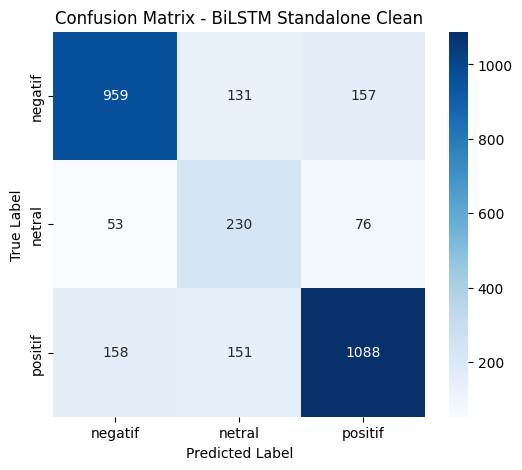

{'model': 'BiLSTM Standalone Clean',
 'accuracy': 0.7582417582417582,
 'precision_macro': 0.6974984468378441,
 'recall_macro': 0.7295086576072762,
 'f1_macro': 0.7074209912668135}

In [38]:
# ============================================================
# 20. PLOT DAN EVALUASI BILSTM CLEAN
# ============================================================

plot_training_history(history_bilstm, "BiLSTM Standalone Clean")

bilstm_result = evaluate_model(bilstm_model, "BiLSTM Standalone Clean")

bilstm_result

In [47]:
# ============================================================
# EVALUASI MODEL BILSTM
# ============================================================

eval_bilstm_detail = evaluasi_detail_model(
    bilstm_model,
    "BiLSTM Standalone"
)


Menghitung prediksi model BiLSTM Standalone pada data uji...

=================== CLASSIFICATION REPORT (BILSTM STANDALONE) ===================
              precision    recall  f1-score   support

     negatif     0.8197    0.7690    0.7935      1247
      netral     0.4492    0.6407    0.5281       359
     positif     0.8236    0.7788    0.8006      1397

    accuracy                         0.7582      3003
   macro avg     0.6975    0.7295    0.7074      3003
weighted avg     0.7772    0.7582    0.7651      3003


===================== RINGKASAN METRIK GLOBAL (BILSTM STANDALONE) =====================
Akurasi Global (Accuracy)        : 0.7582 (75.82%)
Rata-rata Presisi (Macro Prec)   : 0.6975
Rata-rata Recall (Macro Recall)  : 0.7295
Rata-rata F1-Score (Macro F1)    : 0.7074
--------------------------------------------------------------------------------------
Weighted Precision               : 0.7772
Weighted Recall                  : 0.7582
Weighted F1-Score                : 0.

# 21. Model 3 — Hybrid CNN-BiLSTM

Model ketiga adalah Hybrid CNN-BiLSTM.

Model ini menggunakan input gabungan dari embedding teks dan emoji. Setelah embedding teks dan emoji digabung, sequence terlebih dahulu diproses menggunakan CNN untuk menangkap pola lokal. Selanjutnya, hasil ekstraksi fitur dari CNN diproses menggunakan BiLSTM untuk menangkap konteks urutan dari dua arah.

Arsitektur ini dibuat secara sequential, yaitu CNN kemudian BiLSTM, agar lebih sesuai dengan konsep hybrid pada paper acuan.

In [39]:
# ============================================================
# 21. MODEL 3 - HYBRID CNN-BILSTM SEQUENTIAL
# ============================================================

def build_hybrid_cnn_bilstm_model():
    """
    Membangun model Hybrid CNN-BiLSTM sequential.
    Alur:
    Text + Emoji Embedding -> Concatenate -> CNN -> BiLSTM -> Dense -> Softmax
    """

    text_input, emoji_input, merged_sequence = build_shared_text_emoji_embedding()

    # CNN sebagai local feature extractor
    x = Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu',
        padding='same',
        kernel_regularizer=l2(1e-4),
        name='hybrid_conv1d_1'
    )(merged_sequence)

    x = BatchNormalization(name='hybrid_batch_norm_conv1')(x)

    x = MaxPooling1D(
        pool_size=2,
        name='hybrid_max_pooling_1'
    )(x)

    x = Dropout(
        0.25,
        name='hybrid_dropout_after_cnn'
    )(x)

    # CNN tambahan agar fitur lokal lebih kuat sebelum masuk BiLSTM
    x = Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu',
        padding='same',
        kernel_regularizer=l2(1e-4),
        name='hybrid_conv1d_2'
    )(x)

    x = BatchNormalization(name='hybrid_batch_norm_conv2')(x)

    # BiLSTM untuk menangkap konteks dua arah
    x = Bidirectional(
        LSTM(
            64,
            return_sequences=True,
            dropout=0.25,
            recurrent_dropout=0.0
        ),
        name='hybrid_bilstm_layer'
    )(x)

    x = GlobalMaxPooling1D(name='hybrid_global_max_pool')(x)

    x = Dense(
        128,
        activation='relu',
        kernel_regularizer=l2(1e-4),
        name='hybrid_dense_128'
    )(x)

    x = BatchNormalization(name='hybrid_batch_norm_dense')(x)
    x = Dropout(0.35, name='hybrid_dropout_dense')(x)

    output = Dense(
        NUM_CLASSES,
        activation='softmax',
        name='hybrid_output_softmax'
    )(x)

    model = Model(
        inputs=[text_input, emoji_input],
        outputs=output,
        name='Hybrid_CNN_BiLSTM_Text_Emoji'
    )

    model.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


tf.keras.backend.clear_session()

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

hybrid_model = build_hybrid_cnn_bilstm_model()
hybrid_model.summary()

Model: "Hybrid_CNN_BiLSTM_Text_Emoji"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ emoji_input         │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trainable_emoji_em… │ (None, 10, 64)    │      7,936 │ emoji_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word2vec_text_embe… │ (None, 50, 200)   │  3,096,600 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_spatial_drop… │ (None, 10, 64)    │          0 │ trainable_emoji_… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_spatial_dropo… │ (None, 50, 200)   │          0 │ word2vec_text_em… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emoji_projection_t… │ (None, 10, 200)   │     13,000 │ emoji_spatial_dr… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_text_e… │ (None, 60, 200)   │          0 │ text_spatial_dro… │
│ (Concatenate)       │                   │            │ emoji_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_conv1d_1     │ (None, 60, 128)   │     76,928 │ concatenate_text… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_batch_norm_… │ (None, 60, 128)   │        512 │ hybrid_conv1d_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_max_pooling… │ (None, 30, 128)   │          0 │ hybrid_batch_nor… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_dropout_aft… │ (None, 30, 128)   │          0 │ hybrid_max_pooli… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_conv1d_2     │ (None, 30, 128)   │     49,280 │ hybrid_dropout_a… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_batch_norm_… │ (None, 30, 128)   │        512 │ hybrid_conv1d_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_bilstm_layer │ (None, 30, 128)   │     98,816 │ hybrid_batch_nor… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_global_max_… │ (None, 128)       │          0 │ hybrid_bilstm_la… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_dense_128    │ (None, 128)       │     16,512 │ hybrid_global_ma

 Total params: 3,360,995 (12.82 MB)

 Trainable params: 3,360,227 (12.82 MB)

 Non-trainable params: 768 (3.00 KB)

In [40]:
# ============================================================
# 22. TRAINING MODEL 3 - HYBRID CNN-BILSTM CLEAN RUN
# ============================================================

EPOCHS = 50
BATCH_SIZE = 64

start_time = time.time()

history_hybrid = hybrid_model.fit(
    [X_train_text_pad, X_train_emoji_pad],
    y_train,
    validation_data=(
        [X_val_text_pad, X_val_emoji_pad],
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=get_callbacks('v5_hybrid_clean'),
    verbose=1
)

end_time = time.time()
training_time_hybrid = end_time - start_time

print(f"\nWaktu training Hybrid CNN-BiLSTM clean: {training_time_hybrid/60:.2f} menit")

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.3729 - loss: 1.4401
Epoch 1: val_accuracy improved from None to 0.23702, saving model to best_v5_hybrid_clean.keras

Epoch 1: finished saving model to best_v5_hybrid_clean.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 47s 205ms/step - accuracy: 0.3861 - loss: 1.3175 - val_accuracy: 0.2370 - val_loss: 1.2187 - learning_rate: 3.0000e-04
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.4836 - loss: 1.0830
Epoch 2: val_accuracy did not improve from 0.23702
165/165 ━━━━━━━━━━━━━━━━━━━━ 36s 219ms/step - accuracy: 0.5463 - loss: 1.0053 - val_accuracy: 0.1891 - val_loss: 1.2664 - learning_rate: 3.0000e-04
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.6493 - loss: 0.8749
Epoch 3: val_accuracy improved from 0.23702 to 0.50399, saving model to best_v5_hybrid_clean.keras

Epoch 3: finished saving model to best_v5_hybrid_clean.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 36s 216ms/step - accuracy: 0.6654 - loss:

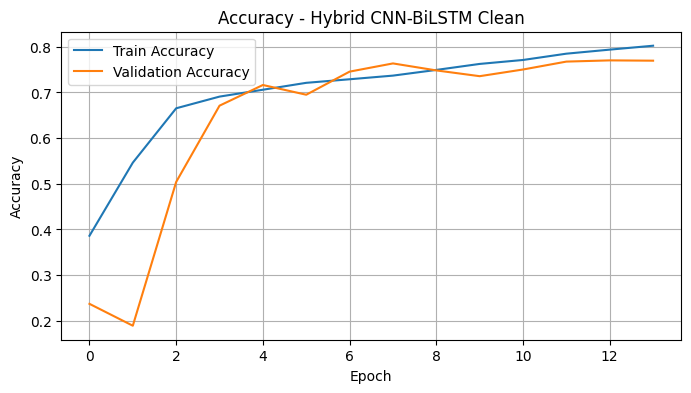

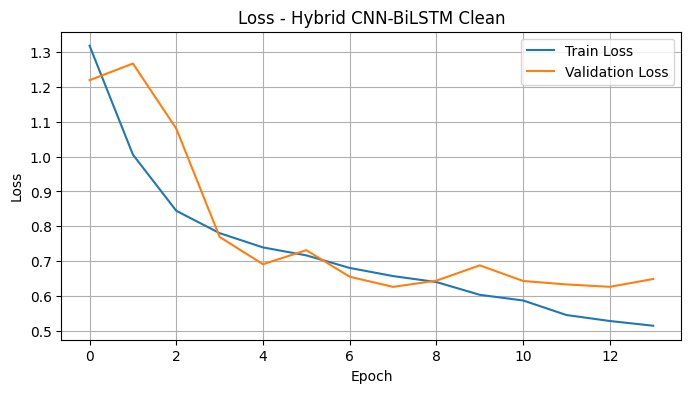

EVALUASI MODEL: Hybrid CNN-BiLSTM Clean
Accuracy        : 0.7449
Precision Macro : 0.6861
Recall Macro    : 0.7240
F1 Macro        : 0.6954

Classification Report:
              precision    recall  f1-score   support

     negatif       0.81      0.78      0.80      1247
      netral       0.42      0.65      0.51       359
     positif       0.83      0.73      0.78      1397

    accuracy                           0.74      3003
   macro avg       0.69      0.72      0.70      3003
weighted avg       0.77      0.74      0.75      3003



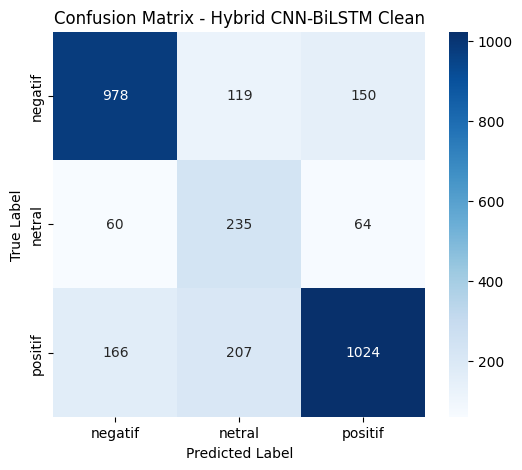

{'model': 'Hybrid CNN-BiLSTM Clean',
 'accuracy': 0.7449217449217449,
 'precision_macro': 0.6861092462455147,
 'recall_macro': 0.7239592206416189,
 'f1_macro': 0.6953802608008308}

In [41]:
# ============================================================
# 23. PLOT DAN EVALUASI HYBRID CNN-BILSTM CLEAN
# ============================================================

plot_training_history(history_hybrid, "Hybrid CNN-BiLSTM Clean")

hybrid_result = evaluate_model(hybrid_model, "Hybrid CNN-BiLSTM Clean")

hybrid_result

In [48]:
# ============================================================
# EVALUASI MODEL HYBRID CNN-BILSTM
# ============================================================

eval_hybrid_detail = evaluasi_detail_model(
    hybrid_model,
    "Hybrid CNN-BiLSTM"
)


Menghitung prediksi model Hybrid CNN-BiLSTM pada data uji...

=================== CLASSIFICATION REPORT (HYBRID CNN-BILSTM) ===================
              precision    recall  f1-score   support

     negatif     0.8123    0.7843    0.7980      1247
      netral     0.4189    0.6546    0.5109       359
     positif     0.8271    0.7330    0.7772      1397

    accuracy                         0.7449      3003
   macro avg     0.6861    0.7240    0.6954      3003
weighted avg     0.7722    0.7449    0.7540      3003


===================== RINGKASAN METRIK GLOBAL (HYBRID CNN-BILSTM) =====================
Akurasi Global (Accuracy)        : 0.7449 (74.49%)
Rata-rata Presisi (Macro Prec)   : 0.6861
Rata-rata Recall (Macro Recall)  : 0.7240
Rata-rata F1-Score (Macro F1)    : 0.6954
--------------------------------------------------------------------------------------
Weighted Precision               : 0.7722
Weighted Recall                  : 0.7449
Weighted F1-Score                : 0.

In [49]:
# ============================================================
# TABEL RINGKAS HASIL EVALUASI DETAIL
# ============================================================

evaluasi_detail_df = pd.DataFrame([
    eval_cnn_detail,
    eval_bilstm_detail,
    eval_hybrid_detail
])

evaluasi_detail_df_display = evaluasi_detail_df.copy()

for col in [
    'accuracy',
    'precision_macro',
    'recall_macro',
    'f1_macro',
    'precision_weighted',
    'recall_weighted',
    'f1_weighted'
]:
    evaluasi_detail_df_display[col] = evaluasi_detail_df_display[col].round(4)

evaluasi_detail_df_display = evaluasi_detail_df_display.sort_values(
    by='f1_macro',
    ascending=False
).reset_index(drop=True)

evaluasi_detail_df_display

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,BiLSTM Standalone,0.7582,0.6975,0.7295,0.7074,0.7772,0.7582,0.7651
1,Hybrid CNN-BiLSTM,0.7449,0.6861,0.7240,0.6954,0.7722,0.7449,0.7540
2,CNN Standalone,0.7486,0.6802,0.6958,0.6858,0.7600,0.7486,0.7533


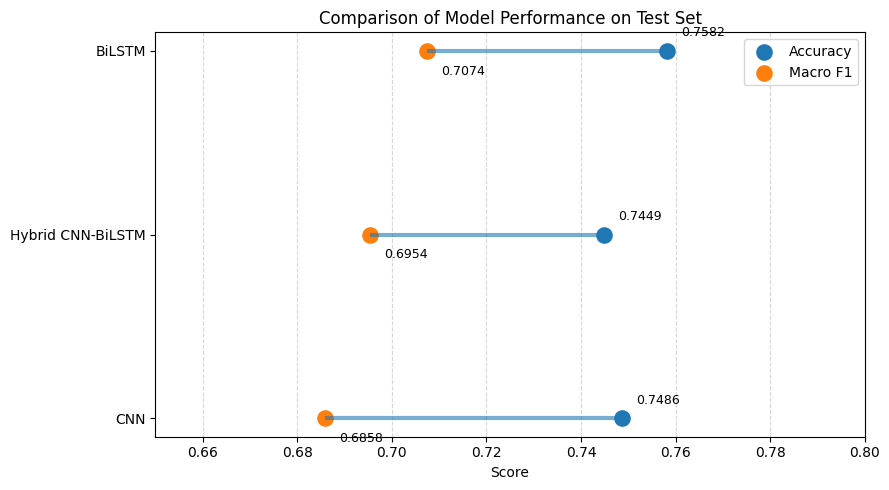

In [50]:
# ============================================================
# VISUALISASI UTAMA - COMPARISON OF 3 METHODS
# Accuracy vs Macro F1
# ============================================================

results_df = pd.DataFrame(results)
results_df = results_df.drop_duplicates(subset='model', keep='last')

# Nama model dibuat lebih ringkas
results_df['model_short'] = results_df['model'].replace({
    'CNN Standalone Clean': 'CNN',
    'BiLSTM Standalone Clean': 'BiLSTM',
    'Hybrid CNN-BiLSTM Clean': 'Hybrid CNN-BiLSTM'
})

# Urutkan berdasarkan Macro F1
plot_df = results_df.sort_values(
    by='f1_macro',
    ascending=True
).reset_index(drop=True)

y_pos = np.arange(len(plot_df))

plt.figure(figsize=(9, 5))

# Garis penghubung Accuracy dan Macro F1
plt.hlines(
    y=y_pos,
    xmin=plot_df['accuracy'],
    xmax=plot_df['f1_macro'],
    linewidth=3,
    alpha=0.6
)

# Titik Accuracy
plt.scatter(
    plot_df['accuracy'],
    y_pos,
    s=120,
    label='Accuracy'
)

# Titik Macro F1
plt.scatter(
    plot_df['f1_macro'],
    y_pos,
    s=120,
    label='Macro F1'
)

# Label angka
for i, row in plot_df.iterrows():
    plt.text(
        row['accuracy'] + 0.003,
        i + 0.08,
        f"{row['accuracy']:.4f}",
        fontsize=9
    )
    plt.text(
        row['f1_macro'] + 0.003,
        i - 0.13,
        f"{row['f1_macro']:.4f}",
        fontsize=9
    )

plt.yticks(y_pos, plot_df['model_short'])
plt.xlabel('Score')
plt.title('Comparison of Model Performance on Test Set')
plt.xlim(0.65, 0.80)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Discussion of Trial Results

## 1. Overall Model Performance

Berdasarkan hasil evaluasi pada test set, **BiLSTM Standalone** menjadi model terbaik secara keseluruhan.

Ringkasan hasil utama:

- **BiLSTM Standalone**
  - Accuracy: 0.7582
  - Macro F1: 0.7074
  - Model terbaik secara keseluruhan.

- **Hybrid CNN-BiLSTM**
  - Accuracy: 0.7449
  - Macro F1: 0.6954
  - Macro F1 lebih tinggi daripada CNN, tetapi belum melampaui BiLSTM.

- **CNN Standalone**
  - Accuracy: 0.7486
  - Macro F1: 0.6858
  - Cukup baik pada kelas negatif dan positif, tetapi lebih lemah pada kelas netral.

## 2. Accuracy vs Macro F1

Accuracy menunjukkan jumlah prediksi benar secara keseluruhan, sedangkan Macro F1 menunjukkan keseimbangan performa model pada semua kelas.

Pada hasil ini, CNN memiliki accuracy sedikit lebih tinggi daripada Hybrid. Namun, Hybrid memiliki Macro F1 lebih tinggi daripada CNN.

Artinya, **Hybrid lebih seimbang dalam mengenali seluruh kelas**, meskipun jumlah prediksi benar totalnya sedikit lebih rendah dibanding CNN.

Macro F1 menjadi penting karena dataset tidak seimbang. Kelas netral memiliki jumlah data paling sedikit, sehingga accuracy saja tidak cukup untuk menilai performa model.

## 3. Performa pada Kelas Netral

Kelas **netral** menjadi kelas yang paling sulit diklasifikasikan oleh semua model.

Hal ini terlihat dari F1 Score kelas netral yang lebih rendah dibanding kelas negatif dan positif.

Penyebabnya:

- jumlah data netral lebih sedikit;
- ekspresi sentimen netral lebih ambigu;
- tweet pendek sering tidak memiliki konteks yang cukup jelas;
- beberapa tweet netral bisa mirip dengan positif atau negatif.

Karena itu, performa model pada kelas netral menjadi tantangan utama dalam eksperimen ini.

## 4. Perbandingan CNN, BiLSTM, dan Hybrid

CNN bekerja cukup baik karena mampu menangkap pola lokal, seperti kata atau frasa pendek yang mengandung sentimen.

BiLSTM bekerja lebih baik karena mampu membaca urutan kata dari dua arah, sehingga konteks kalimat dapat ditangkap dengan lebih stabil.

Hybrid CNN-BiLSTM menggabungkan CNN dan BiLSTM. Model ini berhasil menghasilkan Macro F1 lebih tinggi daripada CNN, tetapi belum mampu melampaui BiLSTM.

Hal ini menunjukkan bahwa penambahan CNN belum selalu meningkatkan performa, terutama karena data yang digunakan berupa tweet pendek. Pada dataset ini, BiLSTM saja sudah cukup efektif untuk menangkap konteks sentimen.

## 5. Final Insight

Model terbaik pada eksperimen ini adalah **BiLSTM Standalone** karena memiliki Accuracy dan Macro F1 tertinggi.

Hybrid CNN-BiLSTM tetap relevan sebagai implementasi pendekatan berbasis paper, karena menggabungkan CNN untuk menangkap pola lokal dan BiLSTM untuk menangkap konteks urutan.

Namun, pada dataset ini, pendekatan Hybrid belum lebih optimal dibanding BiLSTM Standalone.